In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Daily sales load karo
daily_sales = pd.read_csv("daily_sales.csv", parse_dates=['InvoiceDate'])
daily_sales = daily_sales.sort_values('InvoiceDate').reset_index(drop=True)

print(daily_sales.shape)
print(daily_sales.head())

(277, 9)
  InvoiceDate    Revenue  Orders  ItemsSold     Lag_1     Lag_7    Lag_30  \
0  2010-01-14  20000.780      53       8794   9305.98   5668.34  32618.91   
1  2010-01-15  10249.290      41       4606  20000.78  18238.08  29776.63   
2  2010-01-17  12046.780      38       6170  10249.29  17080.99  35324.71   
3  2010-01-18   8832.320      35       4331  12046.78  10626.68  26208.34   
4  2010-01-19  16818.851      44       8101   8832.32  13052.75   8856.29   

   RollingMean_7  RollingMean_30  
0   14196.060000    18425.361667  
1   13054.804286    17774.450333  
2   12335.631429    16998.519333  
3   12079.294286    16419.318667  
4   12617.308714    16684.737367  


# data Preparation 

Date range: 2010-01-14 00:00:00 to 2010-12-09 00:00:00
Total days: 330


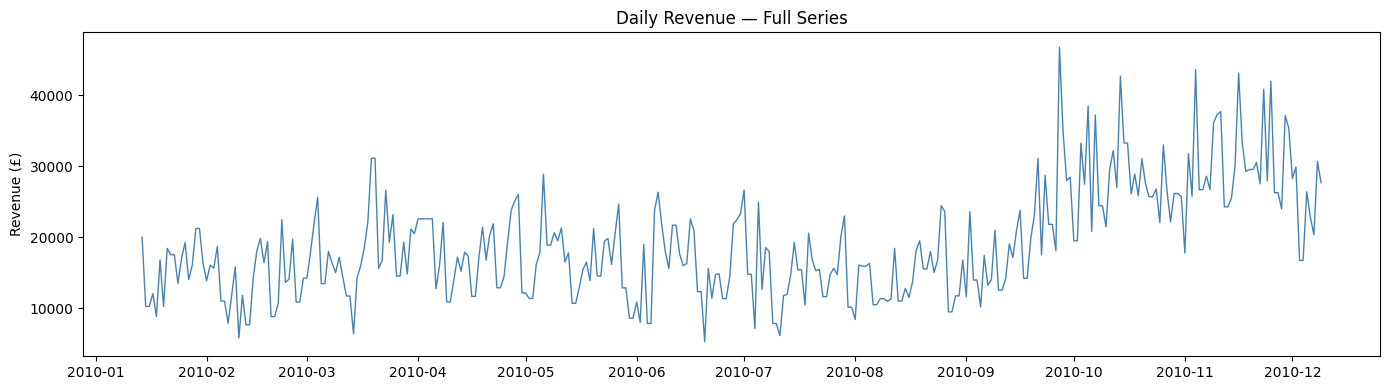

In [2]:

ts = daily_sales[['InvoiceDate', 'Revenue']].copy()
ts = ts.set_index('InvoiceDate')

# Missing dates fill 
ts = ts.asfreq('D')
ts['Revenue'] = ts['Revenue'].ffill()

print(f"Date range: {ts.index.min()} to {ts.index.max()}")
print(f"Total days: {len(ts)}")

# Plot 
plt.figure(figsize=(14, 4))
plt.plot(ts.index, ts['Revenue'], color='steelblue', linewidth=1)
plt.title("Daily Revenue — Full Series")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("plots/ts_raw.png")
plt.show()

# check stationary for Arima

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['Revenue'].dropna())
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")

if result[1] < 0.05:
    print("Series is STATIONARY ") #put arima directly
else:
    print("Series is NON-STATIONARY  ") #do deffrencing

ADF Statistic : -1.2388
p-value       : 0.6567
Series is NON-STATIONARY  


In [5]:
#  differencing for non-stationary
ts['Revenue_diff'] = ts['Revenue'].diff().dropna()

#  check again
result2 = adfuller(ts['Revenue_diff'].dropna())
print(f"After differencing p-value: {result2[1]:.4f}")
# Ab stationary honi chahiye

After differencing p-value: 0.0000


# Arma model

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train/Test split — last 30 days test
train = ts['Revenue'][:-30]
test  = ts['Revenue'][-30:]

# ARIMA(p,d,q) fit karo
# p=5 (AR terms), d=1 (differencing), q=0 (MA terms)
arima_model = ARIMA(train, order=(5, 1, 0))
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  300
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2987.842
Date:                Wed, 03 Jun 2026   AIC                           5987.683
Time:                        16:25:11   BIC                           6009.886
Sample:                    01-14-2010   HQIC                          5996.570
                         - 11-09-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5720      0.055    -10.368      0.000      -0.680      -0.464
ar.L2         -0.3394      0.057     -5.939      0.000      -0.451      -0.227
ar.L3         -0.3337      0.062     -5.382      0.0

In [7]:
# Forecast — next 30 days
arima_forecast = arima_result.forecast(steps=30)

# Metrics calculate 
mae  = mean_absolute_error(test, arima_forecast)
rmse = np.sqrt(mean_squared_error(test, arima_forecast))
mape = np.mean(np.abs((test.values - arima_forecast.values)
               / test.values)) * 100

print(f"\nARIMA Results:")
print(f"MAE  : £{mae:,.0f}")
print(f"RMSE : £{rmse:,.0f}")
print(f"MAPE : {mape:.1f}%")


ARIMA Results:
MAE  : £5,597
RMSE : £6,770
MAPE : 21.8%


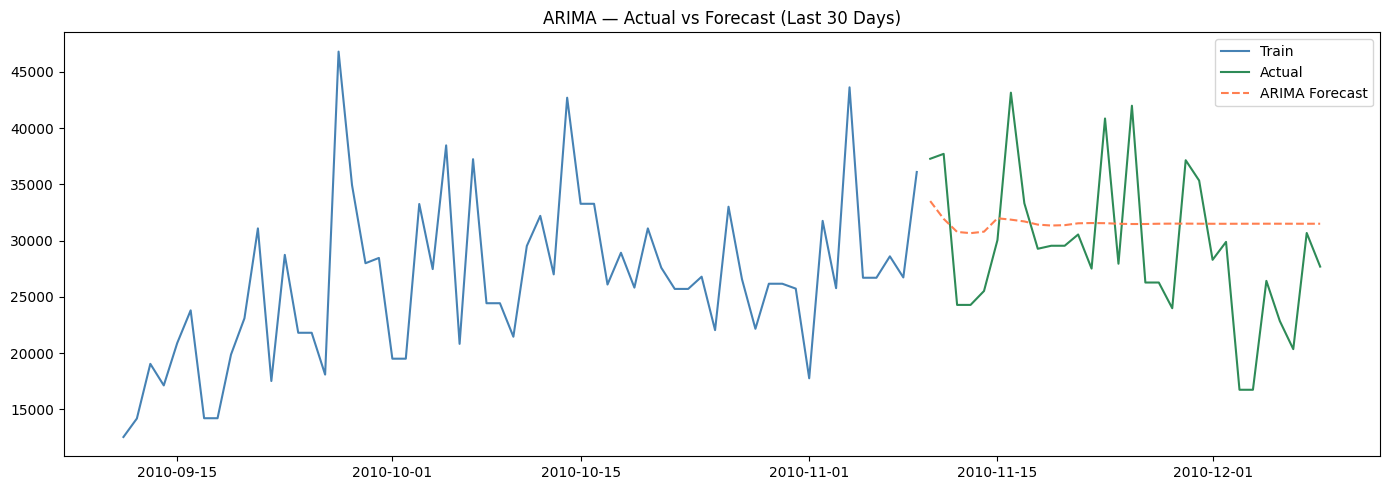

In [8]:
# Plot 
plt.figure(figsize=(14, 5))
plt.plot(train.index[-60:], train.values[-60:],
         label='Train', color='steelblue')
plt.plot(test.index, test.values,
         label='Actual', color='seagreen')
plt.plot(test.index, arima_forecast.values,
         label='ARIMA Forecast', color='coral', linestyle='--')
plt.title("ARIMA — Actual vs Forecast (Last 30 Days)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/arima_forecast.png")
plt.show()

 # Auto ARIMA (best parameters khud dhundta hai)

In [12]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.1 MB 7.5 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.1 MB 5.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.1 MB 5.0 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.1 MB 4.6 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.1 MB 3.7 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.1 MB 3.1 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/12.1 MB 3.0 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 2.9 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/12.1 MB 2.8 MB/s eta 0:00:03
   ------------------- -------------------- 5.8/12.1 MB 2.8 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.1 MB 2.8 MB/s eta 0:00:03
   ----------------------- ---------------- 7.1/12.1 MB 2.8 MB/s eta 0:00:02
   ---

In [11]:

from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=True,
    m=7,              # Weekly seasonality
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    trace=True        # Progress dikhata hai
)

print(f"\nBest order: {auto_model.order}")
print(f"Best seasonal order: {auto_model.seasonal_order}")

# Forecast
auto_forecast = auto_model.predict(n_periods=30)
auto_mae = mean_absolute_error(test, auto_forecast)
print(f"Auto ARIMA MAE: £{auto_mae:,.0f}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.15 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=6074.326, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=5994.727, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=5977.865, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=6072.350, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=5981.994, Time=0.14 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=5928.445, Time=0.61 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=5973.890, Time=0.06 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=0.98 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=1.06 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=5968.218, Time=0.16 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=5959.712, Time=0.16 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=1.26 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.50 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=5930.224, Time=0

In [13]:
# pip install prophet
from prophet import Prophet

# Prophet ko ds aur y columns chahiye
prophet_df = ts.reset_index().rename(
    columns={'InvoiceDate': 'ds', 'Revenue': 'y'}
)[['ds', 'y']]

# Train/test split
prophet_train = prophet_df[:-30]
prophet_test  = prophet_df[-30:]

# Model 
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # Retail ke liye better
    changepoint_prior_scale=0.05        # Trend flexibility
)

# UK holidays add karo 
model.add_country_holidays(country_name='UK')

model.fit(prophet_train)
print("Prophet model trained!")

16:30:06 - cmdstanpy - INFO - Chain [1] start processing
16:30:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained!


In [14]:
# Future dataframe  — 30 days test + 60 days future forecast
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Test period ke liye metrics
test_forecast = forecast[forecast['ds'].isin(prophet_test['ds'])]['yhat']
test_actual   = prophet_test['y'].values

mae_p  = mean_absolute_error(test_actual, test_forecast)
rmse_p = np.sqrt(mean_squared_error(test_actual, test_forecast))
mape_p = np.mean(np.abs((test_actual - test_forecast.values)
                 / test_actual)) * 100

print(f"\nProphet Results:")
print(f"MAE  : £{mae_p:,.0f}")
print(f"RMSE : £{rmse_p:,.0f}")
print(f"MAPE : {mape_p:.1f}%")


Prophet Results:
MAE  : £5,152
RMSE : £6,418
MAPE : 19.8%


# arima vs prophet comparision

In [15]:
print("\n========== MODEL COMPARISON ==========")
print(f"{'Metric':<10} {'ARIMA':>12} {'Prophet':>12}")
print("-" * 36)
print(f"{'MAE':<10} £{mae:>10,.0f} £{mae_p:>10,.0f}")
print(f"{'RMSE':<10} £{rmse:>10,.0f} £{rmse_p:>10,.0f}")
print(f"{'MAPE':<10} {mape:>10.1f}%  {mape_p:>10.1f}%")
print("=" * 36)

best = "Prophet" if mae_p < mae else "ARIMA"
print(f"\nBetter model: {best}")


========== MODEL COMPARISON ==========
Metric            ARIMA      Prophet
------------------------------------
MAE        £     5,597 £     5,152
RMSE       £     6,770 £     6,418
MAPE             21.8%        19.8%

Better model: Prophet


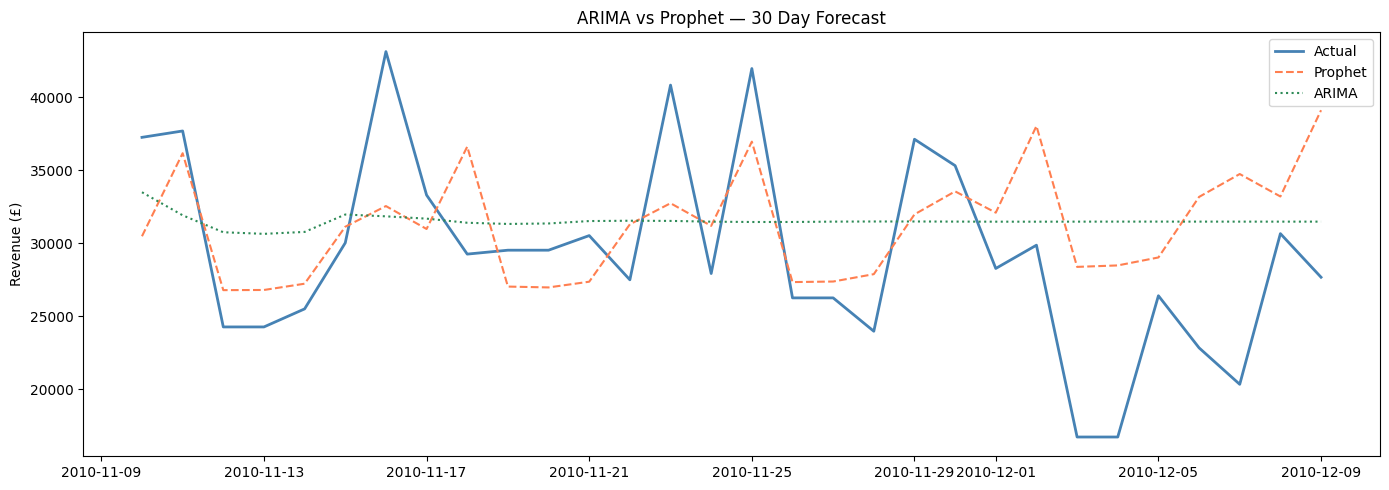

In [16]:
# both in one plot
plt.figure(figsize=(14, 5))
plt.plot(prophet_test['ds'], test_actual,
         label='Actual', color='steelblue', linewidth=2)
plt.plot(prophet_test['ds'], test_forecast.values,
         label='Prophet', color='coral', linestyle='--')
plt.plot(test.index, arima_forecast.values,
         label='ARIMA', color='seagreen', linestyle=':')
plt.title("ARIMA vs Prophet — 30 Day Forecast")
plt.legend()
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("plots/model_comparison.png")
plt.show()

In [18]:
# Future forecast extract 
future_only = forecast[forecast['ds'] > ts.index.max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].head(60)

future_only.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
future_only['Forecast']    = future_only['Forecast'].round(2)
future_only['Lower_Bound'] = future_only['Lower_Bound'].round(2)
future_only['Upper_Bound'] = future_only['Upper_Bound'].round(2)

future_only.to_csv("future_forecast.csv", index=False)
print(future_only.head(10))
print("\nForecast saved!")

          Date  Forecast  Lower_Bound  Upper_Bound
330 2010-12-10  29231.61     23354.34     34295.55
331 2010-12-11  29167.41     23377.29     34769.65
332 2010-12-12  29524.31     24047.35     34947.91
333 2010-12-13  33497.01     28231.85     39097.54
334 2010-12-14  34838.95     29463.62     40371.94
335 2010-12-15  33024.09     27537.68     38405.31
336 2010-12-16  38731.33     33028.44     44038.27
337 2010-12-17  28453.26     22656.79     33381.04
338 2010-12-18  28123.06     22326.42     33444.56
339 2010-12-19  28231.51     22925.69     33965.05

Forecast saved!
